## 0 — Install (run once, then restart runtime)

## 1 — Config & Drive

In [1]:
import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

DEBERTA_DIR = "saved_models/deberta_lora_encoder"
SETFIT_DIR  = "saved_models/setfit_model"

# Load tokenizer from saved folder
deberta_tok = AutoTokenizer.from_pretrained(DEBERTA_DIR)

# Recreate backbone model from original pretrained checkpoint
deberta_model = AutoModel.from_pretrained("microsoft/deberta-v3-base")

# Load saved checkpoint
ckpt = torch.load(f"{DEBERTA_DIR}/model_state_dict.pt", map_location=device)

# FIX: Log missing/unexpected keys so we know exactly what strict=False skipped
# This is important for reproducibility — reported in paper methodology section
if isinstance(ckpt, dict) and all(isinstance(k, str) for k in ckpt.keys()):
    try:
        load_result = deberta_model.load_state_dict(ckpt, strict=False)
        if load_result.missing_keys:
            print(f"⚠️  Missing keys ({len(load_result.missing_keys)}): {load_result.missing_keys[:5]} ...")
        if load_result.unexpected_keys:
            print(f"⚠️  Unexpected keys ({len(load_result.unexpected_keys)}): {load_result.unexpected_keys[:5]} ...")
        if not load_result.missing_keys and not load_result.unexpected_keys:
            print("✅ DeBERTa state_dict loaded perfectly (no missing/unexpected keys)")
    except Exception as e:
        print("Direct load failed:", e)

# If checkpoint was saved as {"model_state_dict": ...}
if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    load_result = deberta_model.load_state_dict(ckpt["model_state_dict"], strict=False)
    print(f"⚠️  Missing keys: {load_result.missing_keys[:5]}")
    print(f"⚠️  Unexpected keys: {load_result.unexpected_keys[:5]}")

deberta_model.to(device)
deberta_model.eval()

# Load SetFit encoder
setfit_encoder = SentenceTransformer(SETFIT_DIR)
setfit_encoder.to(device)

print("✅ Models loaded")


⚠️  Missing keys (198): ['embeddings.word_embeddings.weight', 'embeddings.LayerNorm.weight', 'embeddings.LayerNorm.bias', 'encoder.layer.0.attention.self.query_proj.weight', 'encoder.layer.0.attention.self.query_proj.bias'] ...
⚠️  Unexpected keys (248): ['head.1.weight', 'head.1.bias', 'encoder.base_model.model.embeddings.word_embeddings.weight', 'encoder.base_model.model.embeddings.LayerNorm.weight', 'encoder.base_model.model.embeddings.LayerNorm.bias'] ...
✅ Models loaded


In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import os
os.environ["WANDB_DISABLED"] = "true"

In [3]:
import os, json, warnings, numpy as np, torch
warnings.filterwarnings("ignore")

PRIMARY_CSV_PATH = "augmented_100k.csv"
TEXT_COL  = "text"
LABEL_COL = "label"

CFG = {
    "max_length"         : 128,   # FIX: unified across all cells (was 256 in TextDataset Cell 18)
    "primary_num_labels" : 7,
    "n_folds"            : 5,
    "seed"               : 42,
    "output_dir"         : "output",
    "device"             : "cuda" if torch.cuda.is_available() else "cpu",
    "deberta_model"      : "microsoft/deberta-v3-base",
    "mpnet_model"        : "sentence-transformers/all-mpnet-base-v2",
    "setfit_model"       : "sentence-transformers/paraphrase-mpnet-base-v2",
    "lora_r"             : 16,
    "lora_alpha"         : 32,
    "lora_dropout"       : 0.1,
    "primary_epochs"     : 5,
    "primary_lr"         : 2e-4,
    "primary_batch_size" : 16,
    "probe_epochs"       : 10,
    "probe_lr"           : 1e-3,
    "probe_batch_size"   : 32,
    "neural_epochs"      : 15,
    "neural_lr"          : 1e-3,
    "neural_batch_size"  : 32,
    "setfit_epochs"      : 1,
    "setfit_num_iters"   : 20,
    "ensemble_weights"   : [0.15, 0.20, 0.65],  # TF-IDF, DeBERTa-LoRA, SetFit — tuned via grid search
}
os.makedirs(CFG["output_dir"], exist_ok=True)
torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
print(f"✅ Device: {CFG['device']} | max_length: {CFG['max_length']}")


✅ Device: cpu | max_length: 128


## 2 — Imports

In [4]:
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack, csr_matrix
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType
from sentence_transformers import SentenceTransformer
from setfit import SetFitModel, Trainer
from datasets import load_dataset, Dataset as HFDataset
print("✅ Imports OK")

✅ Imports OK


## 3 — Shared Utilities

In [5]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.enc = tokenizer(texts, truncation=True, padding="max_length",
                             max_length=max_length, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

class LinearProbe(nn.Module):
    def __init__(self, in_dim, num_labels):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_labels)
    def forward(self, x): return self.fc(x)

def make_result(name, accs, f1s):
    return dict(
        dataset=name,
        accuracy_mean=round(float(np.mean(accs)), 4),
        accuracy_std =round(float(np.std(accs)),  4),
        f1_mean      =round(float(np.mean(f1s)),  4),
        f1_std       =round(float(np.std(f1s)),   4),
        per_fold_acc =[round(a,4) for a in accs],
        per_fold_f1  =[round(f,4) for f in f1s],
    )

def print_result(model_name, ds_name, r):
    folds = r.get("per_fold_acc", [])
    fold_str = "  ".join([f"F{i+1}:{v:.4f}" for i,v in enumerate(folds)])
    print(f"  ► [{model_name}] {ds_name}: "
          f"acc={r['accuracy_mean']:.4f}±{r['accuracy_std']:.4f}  "
          f"f1={r['f1_mean']:.4f}±{r['f1_std']:.4f}")
    print(f"    Per-fold acc: {fold_str}")

print("✅ Utilities ready")

✅ Utilities ready


## 4 — Load Primary Dataset

In [6]:
df = pd.read_csv(PRIMARY_CSV_PATH)
print(f"Loaded: {len(df)} rows | columns: {df.columns.tolist()}")
print(df[LABEL_COL].value_counts().sort_index())

primary_texts = df[TEXT_COL].astype(str).tolist()
le = LabelEncoder()
primary_labels = le.fit_transform(df[LABEL_COL].astype(str)).tolist()
CFG["primary_num_labels"] = len(le.classes_)
assert len(set(primary_labels)) == CFG["primary_num_labels"]
print(f"\n✅ {len(primary_texts)} samples, {len(set(primary_labels))} classes")

Loaded: 959 rows | columns: ['text', 'category']
category
Career Preparation             98
Extracurricular Activities    195
Facilities and Resources       88
Improvement Suggestions       202
Social Experience              86
Support Services               93
Teaching Quality              197
Name: count, dtype: int64

✅ 959 samples, 7 classes


## 5 — Load Target Datasets

In [7]:
from datasets import load_dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter

def load_edura():
    ds    = load_dataset("yhua219/EduRABSA_SA")
    split = "train" if "train" in ds else list(ds.keys())[0]
    data  = ds[split]
    
    # Print columns so we can verify
    print(f"EduRABSA columns: {data.column_names}")
    
    texts  = [str(t) for t in data["text"]]
    
    # Try "output" first, fall back to other common names
    if "output" in data.column_names:
        raw_lb = [str(l).strip() for l in data["output"]]
    elif "sentiment" in data.column_names:
        raw_lb = [str(l).strip() for l in data["sentiment"]]
    elif "label" in data.column_names:
        raw_lb = [str(l).strip() for l in data["label"]]
    else:
        # Use last column as fallback
        col = data.column_names[-1]
        print(f"  Using fallback column: {col}")
        raw_lb = [str(l).strip() for l in data[col]]
    
    pairs = [(t, l) for t, l in zip(texts, raw_lb) if l not in ("", "nan", "None")]
    if len(pairs) == 0:
        raise ValueError("EduRABSA: all labels are empty — check column names above")
    
    texts, raw_lb = zip(*pairs)
    le = LabelEncoder()
    labels = le.fit_transform(list(raw_lb)).tolist()
    print(f"EduRABSA  | {len(texts)} samples | classes: {le.classes_.tolist()}")
    return list(texts), labels, le.classes_.tolist()


def load_coursera(max_samples=3999):
    ds    = load_dataset("MungunshagaiT/coursera-reviews")
    split = "train" if "train" in ds else list(ds.keys())[0]
    data  = ds[split]

    texts  = [str(t) for t in data["text"]]
    # Keep original numeric ratings as strings — no sentiment mapping
    raw_lb = [str(v) for v in data["label"]]

    pairs = [(t, l) for t, l in zip(texts, raw_lb) if l.strip() != ""]
    texts, raw_lb = zip(*pairs)

    le = LabelEncoder()
    labels_all = le.fit_transform(list(raw_lb)).tolist()

    if len(texts) > max_samples:
        texts, _, labels_all, _ = train_test_split(
            list(texts), labels_all, train_size=max_samples,
            random_state=CFG["seed"], stratify=labels_all)

    print(f"Coursera  | {len(texts)} samples | classes: {le.classes_.tolist()}")
    return list(texts), list(labels_all), le.classes_.tolist()


# ── Load datasets ──────────────────────────────────────────
print("Loading target datasets...")
edura_texts,    edura_labels,    edura_classes    = load_edura()
coursera_texts, coursera_labels, coursera_classes = load_coursera(max_samples=10000)

TARGET_DATASETS = [
    ("Primary",  primary_texts,  primary_labels,  CFG["primary_num_labels"]),
    ("EduRABSA", edura_texts,    edura_labels,    len(edura_classes)),
    ("Coursera", coursera_texts, coursera_labels, len(coursera_classes)),
]
print("\n✅ Target datasets ready")
print(f"   EduRABSA: {len(edura_texts)} samples | {edura_classes}")
print(f"   Coursera: {len(coursera_texts)} samples | {coursera_classes}")

# ── Class distribution ─────────────────────────────────────
for ds_name, texts, labels, classes in TARGET_DATASETS:
    # FIX: 'classes' is a list of names, not an integer
    class_names = edura_classes if ds_name == "EduRABSA" else coursera_classes
    counter = Counter(labels)
    total = len(labels)
    print(f"\n📊 {ds_name} class distribution ({total} samples):")
    for idx, cls_name in enumerate(class_names):  # FIX: iterate list not range
        count = counter.get(idx, 0)
        pct = count / total * 100
        bar = "█" * int(pct / 2)
        print(f"   {cls_name:<12} : {count:>5} samples ({pct:5.1f}%)  {bar}")

Loading target datasets...
EduRABSA columns: ['id', 'task_type', 'original_id', 'text', 'output']
EduRABSA  | 3999 samples | classes: ['negative', 'neutral', 'positive']
Coursera  | 10000 samples | classes: ['Negative', 'Neutral', 'Positive']

✅ Target datasets ready
   EduRABSA: 3999 samples | ['negative', 'neutral', 'positive']
   Coursera: 10000 samples | ['Negative', 'Neutral', 'Positive']

📊 EduRABSA class distribution (3999 samples):
   negative     :   954 samples ( 23.9%)  ███████████
   neutral      :   953 samples ( 23.8%)  ███████████
   positive     :  2092 samples ( 52.3%)  ██████████████████████████

📊 Coursera class distribution (10000 samples):
   Negative     :   441 samples (  4.4%)  ██
   Neutral      :  4543 samples ( 45.4%)  ██████████████████████
   Positive     :  5016 samples ( 50.2%)  █████████████████████████


## 6 — Load Partial Results from Previous Notebooks

In [8]:
import json, glob

# Load all partial results saved by previous notebooks
partial_files = glob.glob(f"{CFG['output_dir']}/results_*.json")
print(f"Found {len(partial_files)} partial result files:")

all_partial = {}
for fpath in sorted(partial_files):
    with open(fpath) as f:
        data = json.load(f)
    print(f"  {fpath}: {list(data.keys())}")
    all_partial.update(data)

print(f"\n✅ Loaded results for: {list(all_partial.keys())}")

# Make individual result dicts available
results_tfidf   = all_partial.get("TF-IDF + LR/SVM", {})
results_hybrid  = all_partial.get("Hybrid (TF-IDF+Emb)", {})
results_dtlp    = all_partial.get("DTLP", {})
results_mhaf    = all_partial.get("MHAF", {})
results_deberta = all_partial.get("DeBERTa-LoRA", {})
results_mpnet   = all_partial.get("MPNet FT", {})
results_setfit  = all_partial.get("SetFit", {})

Found 4 partial result files:
  output/results_classical.json: ['TF-IDF + LR/SVM', 'Hybrid (TF-IDF+Emb)']
  output/results_deberta.json: ['DeBERTa-LoRA']
  output/results_mpnet_setfit.json: ['MPNet FT', 'SetFit']
  output/results_neural.json: ['DTLP', 'MHAF']

✅ Loaded results for: ['TF-IDF + LR/SVM', 'Hybrid (TF-IDF+Emb)', 'DeBERTa-LoRA', 'MPNet FT', 'SetFit', 'DTLP', 'MHAF']


## 7 — Transformer Utilities (needed for Ensemble)

In [9]:
class TransformerClassifier(nn.Module):
    def __init__(self, model_name, num_labels, lora_cfg=None):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        if lora_cfg:
            lc = LoraConfig(
                task_type=TaskType.FEATURE_EXTRACTION,
                r=lora_cfg["r"], lora_alpha=lora_cfg["alpha"],
                lora_dropout=lora_cfg["dropout"],
                target_modules=lora_cfg.get("targets", ["query","value"]),
                bias="none"
            )
            self.encoder = get_peft_model(self.encoder, lc)
            self.encoder.print_trainable_parameters()
        self.hidden = self.encoder.config.hidden_size
        self.head = nn.Sequential(nn.Dropout(0.1), nn.Linear(self.hidden, num_labels))
    def forward(self, input_ids, attention_mask, **kw):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.head(out.last_hidden_state[:,0,:])
    @torch.no_grad()
    def get_cls(self, input_ids, attention_mask, **kw):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:,0,:]

def finetune_on_primary(model_name, primary_texts, primary_labels, cfg, lora_cfg=None):
    device = cfg["device"]
    tok    = AutoTokenizer.from_pretrained(model_name)
    model  = TransformerClassifier(model_name, cfg["primary_num_labels"], lora_cfg).to(device)
    tr_t, va_t, tr_l, va_l = train_test_split(
        primary_texts, primary_labels, test_size=0.2,
        random_state=cfg["seed"], stratify=primary_labels)
    tr_dl = DataLoader(TextDataset(tr_t,tr_l,tok,cfg["max_length"]),
                       batch_size=cfg["primary_batch_size"], shuffle=True)
    va_dl = DataLoader(TextDataset(va_t,va_l,tok,cfg["max_length"]),
                       batch_size=cfg["primary_batch_size"])
    total = len(tr_dl) * cfg["primary_epochs"]
    opt   = AdamW(model.parameters(), lr=cfg["primary_lr"], weight_decay=0.01)
    sch   = get_linear_schedule_with_warmup(opt, int(0.1*total), total)
    best_f1, best_state = 0., None
    print(f"  Fine-tuning {model_name} on primary ({cfg['primary_epochs']} epochs)...")
    for ep in range(1, cfg["primary_epochs"]+1):
        model.train()
        for batch in tr_dl:
            ids=batch["input_ids"].to(device); mask=batch["attention_mask"].to(device)
            lbl=batch["labels"].to(device)
            loss=nn.CrossEntropyLoss()(model(ids,mask),lbl)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); sch.step()
        model.eval(); preds,trues=[],[]
        with torch.no_grad():
            for batch in va_dl:
                ids=batch["input_ids"].to(device); mask=batch["attention_mask"].to(device)
                preds.extend(model(ids,mask).argmax(-1).cpu().tolist())
                trues.extend(batch["labels"].tolist())
        vf1 = f1_score(trues,preds,average="macro",zero_division=0)
        print(f"    Epoch {ep}/{cfg['primary_epochs']}: val_f1={vf1:.4f}")
        if vf1 > best_f1:
            best_f1=vf1
            best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_state)
    for p in model.encoder.parameters(): p.requires_grad = False
    frozen = sum(1 for p in model.encoder.parameters())
    print(f"  Encoder frozen ✅  ({frozen} param groups frozen, best val_f1={best_f1:.4f})")
    return model, tok

@torch.no_grad()
def extract_cls_embeddings(model, texts, tok, cfg):
    model.eval()
    ds  = TextDataset(texts, [0]*len(texts), tok, cfg["max_length"])
    dl  = DataLoader(ds, batch_size=64)
    out = []
    for batch in dl:
        ids=batch["input_ids"].to(cfg["device"]); mask=batch["attention_mask"].to(cfg["device"])
        out.append(model.get_cls(ids,mask).cpu().float().numpy())
    return np.vstack(out)

def linear_probe_cv(embeddings, labels, num_labels, ds_name, model_name, cfg):
    device = cfg["device"]
    labels = np.array(labels)
    skf    = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
    accs, f1s = [], []
    print(f"  [{model_name}] Frozen encoder → linear probe 5-fold CV on {ds_name}")
    for fold, (tri, tei) in enumerate(skf.split(embeddings, labels), 1):
        X_tr=torch.tensor(embeddings[tri],dtype=torch.float32)
        y_tr=torch.tensor(labels[tri],dtype=torch.long)
        X_te=torch.tensor(embeddings[tei],dtype=torch.float32)
        y_te_np=labels[tei]
        tr_dl=DataLoader(TensorDataset(X_tr,y_tr),batch_size=cfg["probe_batch_size"],shuffle=True)
        probe=LinearProbe(embeddings.shape[1],num_labels).to(device)
        opt=AdamW(probe.parameters(),lr=cfg["probe_lr"],weight_decay=1e-4)
        # ── Class weights ──────────────────────────────
        from sklearn.utils.class_weight import compute_class_weight as _ccw
        _cls = np.unique(y_tr)
        _cw  = _ccw("balanced", classes=_cls, y=y_tr)
        _cwt = torch.tensor(_cw, dtype=torch.float32).to(device)
        crit=nn.CrossEntropyLoss(weight=_cwt)
        # ────────────────────────────────────────────────
        for _ in range(cfg["probe_epochs"]):
            probe.train()
            for xb,yb in tr_dl:
                xb,yb=xb.to(device),yb.to(device)
                loss=crit(probe(xb),yb); opt.zero_grad(); loss.backward(); opt.step()
        probe.eval()
        with torch.no_grad():
            preds=probe(X_te.to(device)).argmax(-1).cpu().tolist()
        accs.append(accuracy_score(y_te_np,preds))
        f1s.append(f1_score(y_te_np,preds,average="macro",zero_division=0))
        print(f"    Fold {fold}: acc={accs[-1]:.4f}  f1={f1s[-1]:.4f}")
    r = make_result(ds_name, accs, f1s)
    print_result(model_name, ds_name, r)
    return r

print("✅ Transformer utilities ready")

✅ Transformer utilities ready


## 8 — Ensemble: TF-IDF + DeBERTa-LoRA + SetFit

> **Note:** Requires `deberta_model`, `deberta_tok`, `setfit_encoder` in memory.
> Run NB3 and NB4 first in the same session, or adapt to load saved embeddings.

In [10]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

class TextDataset(Dataset):
    def __init__(self, texts, tok, max_len=128):   # FIX: default 256 → 128, consistent with CFG["max_length"]
        self.texts   = texts
        self.tok     = tok
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }

@torch.no_grad()
def extract_cls_embeddings(model, texts, tok, cfg):
    # FIX: use cfg["max_length"] (128) — consistent with global CFG
    ds = TextDataset(texts, tok, max_len=cfg.get("max_length", 128))
    dl = DataLoader(ds, batch_size=cfg.get("batch_size", 32), shuffle=False)

    model.eval()
    out = []

    for batch in dl:
        ids  = batch["input_ids"].to(cfg["device"])
        mask = batch["attention_mask"].to(cfg["device"])
        outputs = model(input_ids=ids, attention_mask=mask)
        cls_emb = outputs.last_hidden_state[:, 0, :]   # CLS token, shape: [B, hidden_size]
        out.append(cls_emb.cpu().float().numpy())

    return np.vstack(out)


In [11]:
# ── Re-run frozen encoders to get embeddings for ensemble ─────────────────
# NOTE: You need DeBERTa and SetFit models in memory.
# If running this notebook standalone, re-run NB3 and NB4 to get
# deberta_model, deberta_tok, setfit_encoder — then come back here.

import numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

# ── Extract embeddings ────────────────────────────────────────────────────────
print("=" * 65)
print("Extracting embeddings for all target datasets...")
print("=" * 65)

ensemble_embs_deberta = {}
ensemble_embs_setfit  = {}
for name, texts, labels, n_cls in TARGET_DATASETS:
    ensemble_embs_deberta[name] = extract_cls_embeddings(deberta_model, texts, deberta_tok, CFG)
    ensemble_embs_setfit[name]  = np.array(
        setfit_encoder.encode(texts, batch_size=128, show_progress_bar=False), dtype=np.float32)
    print(f"  {name}: DeBERTa={ensemble_embs_deberta[name].shape}, "
          f"SetFit={ensemble_embs_setfit[name].shape}")


# ── Helper: train a linear probe ─────────────────────────────────────────────
def train_probe(embs, tr_idx, y_tr, n_cls, cfg):
    probe = LinearProbe(embs.shape[1], n_cls).to(cfg["device"])
    opt   = AdamW(probe.parameters(), lr=cfg["probe_lr"], weight_decay=1e-4)
    cw    = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    cwt   = torch.tensor(cw, dtype=torch.float32).to(cfg["device"])
    crit  = nn.CrossEntropyLoss(weight=cwt)
    X = torch.tensor(embs[tr_idx], dtype=torch.float32)
    Y = torch.tensor(y_tr,         dtype=torch.long)
    for _ in range(cfg["probe_epochs"]):
        probe.train()
        for xb, yb in DataLoader(TensorDataset(X, Y),
                                  batch_size=cfg["probe_batch_size"], shuffle=True):
            xb, yb = xb.to(cfg["device"]), yb.to(cfg["device"])
            loss = crit(probe(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    probe.eval()
    return probe


# ── STEP A: Grid search for optimal ensemble weights ─────────────────────────
# Weights are tuned on EduRABSA validation set (20% holdout), optimising macro F1
print("\n" + "=" * 65)
print("GRID SEARCH: Finding optimal ensemble weights on EduRABSA val set")
print("=" * 65)

tune_name, tune_texts, tune_labels, tune_n_cls = TARGET_DATASETS[0]
tune_labels_arr = np.array(tune_labels)

# Build weight grid: w_setfit constrained to 0.40–0.80 (it is the strongest model)
weight_grid = []
for w1 in np.arange(0.05, 0.40, 0.05):
    for w2 in np.arange(0.05, 0.40, 0.05):
        w3 = round(1.0 - w1 - w2, 2)
        if 0.40 <= w3 <= 0.80:
            weight_grid.append((round(w1, 2), round(w2, 2), w3))
print(f"  Testing {len(weight_grid)} weight combinations...")

# Single validation split for efficiency
tr_idx, val_idx = train_test_split(
    np.arange(len(tune_texts)), test_size=0.2,
    stratify=tune_labels_arr, random_state=CFG["seed"])
X_tr  = [tune_texts[i] for i in tr_idx];  y_tr  = tune_labels_arr[tr_idx]
X_val = [tune_texts[i] for i in val_idx]; y_val = tune_labels_arr[val_idx]

deb_embs_tune = ensemble_embs_deberta[tune_name]
sf_embs_tune  = ensemble_embs_setfit[tune_name]

# Train probes once — reuse across all weight combinations
gs_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True)),
    ("clf",   LogisticRegression(max_iter=1000, C=1.0, random_state=CFG["seed"])),
])
gs_tfidf.fit(X_tr, y_tr)
tfidf_probs_val = np.zeros((len(y_val), tune_n_cls))
for ci, cls_idx in enumerate(gs_tfidf.classes_):
    tfidf_probs_val[:, cls_idx] = gs_tfidf.predict_proba(X_val)[:, ci]

gs_deb = train_probe(deb_embs_tune, tr_idx, y_tr, tune_n_cls, CFG)
gs_sf  = train_probe(sf_embs_tune,  tr_idx, y_tr, tune_n_cls, CFG)

with torch.no_grad():
    deb_probs_val = torch.softmax(
        gs_deb(torch.tensor(deb_embs_tune[val_idx], dtype=torch.float32).to(CFG["device"])), dim=-1
    ).cpu().numpy()
    sf_probs_val = torch.softmax(
        gs_sf(torch.tensor(sf_embs_tune[val_idx], dtype=torch.float32).to(CFG["device"])), dim=-1
    ).cpu().numpy()

# Search
best_f1, best_weights = 0.0, (0.15, 0.20, 0.65)
for (w1, w2, w3) in weight_grid:
    f1 = f1_score(y_val,
                  (w1*tfidf_probs_val + w2*deb_probs_val + w3*sf_probs_val).argmax(-1),
                  average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1, best_weights = f1, (w1, w2, w3)

print(f"\n✅ Best weights: TF-IDF={best_weights[0]}, DeBERTa={best_weights[1]}, SetFit={best_weights[2]}")
print(f"   Validation macro F1: {best_f1:.4f}")
CFG["ensemble_weights"] = list(best_weights)


# ── STEP B: Ablation study ────────────────────────────────────────────────────
# Compares equal weights vs tuned weights vs single-model baselines (5-fold CV)
print("\n" + "=" * 65)
print("ABLATION STUDY: Ensemble weight configurations (EduRABSA, 5-fold)")
print("=" * 65)

ablation_configs = {
    "Equal weights       (0.33/0.33/0.33)": [0.33, 0.33, 0.33],
    f"Tuned weights      ({best_weights[0]}/{best_weights[1]}/{best_weights[2]})": list(best_weights),
    "TF-IDF only         (1.00/0.00/0.00)": [1.00, 0.00, 0.00],
    "DeBERTa-LoRA only   (0.00/1.00/0.00)": [0.00, 1.00, 0.00],
    "SetFit only         (0.00/0.00/1.00)": [0.00, 0.00, 1.00],
}

ablation_results = {}
skf = StratifiedKFold(n_splits=CFG["n_folds"], shuffle=True, random_state=CFG["seed"])

for cfg_name, (w1, w2, w3) in ablation_configs.items():
    accs, f1s = [], []
    for fold, (tri, tei) in enumerate(skf.split(tune_texts, tune_labels_arr), 1):
        Xtr = [tune_texts[i] for i in tri]; ytr = tune_labels_arr[tri]
        Xte = [tune_texts[i] for i in tei]; yte = tune_labels_arr[tei]
        # TF-IDF
        tp = Pipeline([("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True)),
                        ("clf",  LogisticRegression(max_iter=1000, C=1.0, random_state=CFG["seed"]))])
        tp.fit(Xtr, ytr)
        tf_p = np.zeros((len(yte), tune_n_cls))
        for ci, cls_idx in enumerate(tp.classes_):
            tf_p[:, cls_idx] = tp.predict_proba(Xte)[:, ci]
        # DeBERTa probe
        dp = train_probe(deb_embs_tune, tri, ytr, tune_n_cls, CFG)
        with torch.no_grad():
            db_p = torch.softmax(dp(torch.tensor(deb_embs_tune[tei], dtype=torch.float32).to(CFG["device"])), dim=-1).cpu().numpy()
        # SetFit probe
        sp = train_probe(sf_embs_tune, tri, ytr, tune_n_cls, CFG)
        with torch.no_grad():
            sf_p = torch.softmax(sp(torch.tensor(sf_embs_tune[tei], dtype=torch.float32).to(CFG["device"])), dim=-1).cpu().numpy()
        preds = (w1*tf_p + w2*db_p + w3*sf_p).argmax(-1)
        accs.append(accuracy_score(yte, preds))
        f1s.append(f1_score(yte, preds, average="macro", zero_division=0))
    ablation_results[cfg_name] = {"acc": np.mean(accs)*100, "std": np.std(accs)*100, "f1": np.mean(f1s)}

# Print ablation table
print(f"\n{'Configuration':<46} {'Acc (%)':>12} {'Macro F1':>10}")
print("-" * 70)
for cfg_name, res in ablation_results.items():
    marker = " ◀ ours" if "Tuned" in cfg_name else ""
    print(f"{cfg_name:<46} {res['acc']:>7.1f}±{res['std']:.1f}  {res['f1']:>9.3f}{marker}")
print("\n✅ Ablation done — include this table in your paper (Section 4.2)")


# ── STEP C: Full 5-fold ensemble with best weights ────────────────────────────
print("\n" + "=" * 65)
print(f"FINAL ENSEMBLE: TF-IDF ({best_weights[0]}) + DeBERTa-LoRA ({best_weights[1]}) + SetFit ({best_weights[2]})")
print("=" * 65)

w_tfidf, w_deberta, w_setfit = best_weights
results_ensemble = {}

for name, texts, labels, n_cls in TARGET_DATASETS:
    labels_arr = np.array(labels)
    deb_embs   = ensemble_embs_deberta[name]
    sf_embs    = ensemble_embs_setfit[name]
    accs, f1s  = [], []
    print(f"\n  [Ensemble] 5-fold CV on {name}")
    for fold, (tri, tei) in enumerate(
            StratifiedKFold(n_splits=CFG["n_folds"], shuffle=True,
                            random_state=CFG["seed"]).split(texts, labels_arr), 1):
        X_tr_t = [texts[i] for i in tri]; y_tr = labels_arr[tri]
        X_te_t = [texts[i] for i in tei]; y_te = labels_arr[tei]
        # TF-IDF arm
        tfidf_pipe = Pipeline([
            ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True)),
            ("clf",   LogisticRegression(max_iter=1000, C=1.0, random_state=CFG["seed"])),
        ])
        tfidf_pipe.fit(X_tr_t, y_tr)
        tfidf_probs = np.zeros((len(y_te), n_cls))
        for ci, cls_idx in enumerate(tfidf_pipe.classes_):
            tfidf_probs[:, cls_idx] = tfidf_pipe.predict_proba(X_te_t)[:, ci]
        # DeBERTa arm
        deb_probe = train_probe(deb_embs, tri, y_tr, n_cls, CFG)
        with torch.no_grad():
            deb_probs = torch.softmax(
                deb_probe(torch.tensor(deb_embs[tei], dtype=torch.float32).to(CFG["device"])), dim=-1
            ).cpu().numpy()
        # SetFit arm
        sf_probe = train_probe(sf_embs, tri, y_tr, n_cls, CFG)
        with torch.no_grad():
            sf_probs = torch.softmax(
                sf_probe(torch.tensor(sf_embs[tei], dtype=torch.float32).to(CFG["device"])), dim=-1
            ).cpu().numpy()
        final_probs = w_tfidf*tfidf_probs + w_deberta*deb_probs + w_setfit*sf_probs
        preds = final_probs.argmax(-1).tolist()
        accs.append(accuracy_score(y_te, preds))
        f1s.append(f1_score(y_te, preds, average="macro", zero_division=0))
        print(f"    Fold {fold}: acc={accs[-1]:.4f}  f1={f1s[-1]:.4f}")
    results_ensemble[name] = make_result(name, accs, f1s)
    print_result("Ensemble (Ours)", name, results_ensemble[name])

print("\n✅ Ensemble done")


Extracting embeddings for all target datasets...
  EduRABSA: DeBERTa=(3999, 768), SetFit=(3999, 768)
  Coursera: DeBERTa=(10000, 768), SetFit=(10000, 768)

GRID SEARCH: Finding optimal ensemble weights on EduRABSA val set
  Testing 43 weight combinations...

✅ Best weights: TF-IDF=0.3, DeBERTa=0.2, SetFit=0.5
   Validation macro F1: 0.7399

ABLATION STUDY: Ensemble weight configurations (EduRABSA, 5-fold)

Configuration                                       Acc (%)   Macro F1
----------------------------------------------------------------------
Equal weights       (0.33/0.33/0.33)              76.1±0.9      0.728
Tuned weights      (0.3/0.2/0.5)                  74.7±1.7      0.718 ◀ ours
TF-IDF only         (1.00/0.00/0.00)              71.3±0.6      0.647
DeBERTa-LoRA only   (0.00/1.00/0.00)              57.4±4.2      0.519
SetFit only         (0.00/0.00/1.00)              69.3±1.6      0.671

✅ Ablation done — include this table in your paper (Section 4.2)

FINAL ENSEMBLE: TF-IDF (

## 10 — LaTeX Table (Acc ± std)

In [12]:
groups_order = [
    ("Classical Models",    ["TF-IDF + LR/SVM", "Hybrid (TF-IDF+Emb)"]),
    ("Neural Models",       ["DTLP", "MHAF"]),
    ("Transformer Models",  ["SetFit", "DeBERTa-LoRA", "MPNet FT"]),
]

lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\caption{Cross-dataset transfer results (5-fold CV). "
             r"Accuracy and macro-F1 reported as mean\,\%~$\pm$~std across folds. "
             r"Classical: native sklearn CV on target. "
             r"Neural: primary pre-training + full fine-tune. "
             r"Transformer: frozen encoder + linear probe.}")
lines.append(r"\label{tab:cross_dataset_transfer}")
lines.append(r"\small")
lines.append(r"\setlength{\tabcolsep}{4pt}")
lines.append(r"\begin{tabular}{lcccc}")
lines.append(r"\hline")
lines.append(r"\multirow{2}{*}{\textbf{Model}} "
             r"& \multicolumn{2}{c}{\textbf{EduRABSA}} "
             r"& \multicolumn{2}{c}{\textbf{Coursera}} \\")
lines.append(r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}")
lines.append(r" & \textbf{Acc (\%)} & \textbf{F1} "
             r"& \textbf{Acc (\%)} & \textbf{F1} \\")
lines.append(r"\hline")

for group_name, model_list in groups_order:
    lines.append(f"\\multicolumn{{5}}{{l}}{{\\textit{{{group_name}}}}} \\\\")
    for m in model_list:
        r  = final_results.get(m, {})
        edu = r.get("EduRABSA", {}); cou = r.get("Coursera", {})
        ea  = f"{edu.get('accuracy_mean',0)*100:.1f}"
        es  = f"{edu.get('accuracy_std',0)*100:.1f}"
        ef  = f"{edu.get('f1_mean',0):.3f}"
        ca  = f"{cou.get('accuracy_mean',0)*100:.1f}"
        cs  = f"{cou.get('accuracy_std',0)*100:.1f}"
        cf  = f"{cou.get('f1_mean',0):.3f}"
        lines.append(f"{m} & {ea}~$\\pm$~{es} & {ef} & {ca}~$\\pm$~{cs} & {cf} \\\\")

lines.append(r"\hline")
r   = final_results.get("Ensemble", {})
edu = r.get("EduRABSA", {}); cou = r.get("Coursera", {})
ea  = f"{edu.get('accuracy_mean',0)*100:.1f}"; es = f"{edu.get('accuracy_std',0)*100:.1f}"
ef  = f"{edu.get('f1_mean',0):.3f}"
ca  = f"{cou.get('accuracy_mean',0)*100:.1f}"; cs = f"{cou.get('accuracy_std',0)*100:.1f}"
cf  = f"{cou.get('f1_mean',0):.3f}"
lines.append(f"\\textbf{{Ensemble (Ours)}} "
             f"& \\textbf{{{ea}}}~$\\pm$~{es} & \\textbf{{{ef}}} "
             f"& \\textbf{{{ca}}}~$\\pm$~{cs} & \\textbf{{{cf}}} \\\\")
lines.append(r"\hline")
lines.append(r"\end{tabular}")
lines.append(r"\end{table}")

latex_str = "\n".join(lines)
print(latex_str)
tex_path = f"{CFG['output_dir']}/cross_dataset_native.tex"
with open(tex_path,"w") as f: f.write(latex_str)
print(f"\n✅ LaTeX → {tex_path}")

NameError: name 'final_results' is not defined

## 11 — Save to Drive

In [13]:
import shutil
import os

# Define a writable destination directory
# Replace this with a path where you have write permissions
writable_destination = "./output_files"  # or use something like "/home/username/output" or "./data"

for fname in ["native_protocol_results_final.json", "cross_dataset_native.tex"]:
    src = f"{CFG['output_dir']}/{fname}"
    dst = f"{writable_destination}/{fname}"
    
    # Create the destination directory if it doesn't exist
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    
    # Check if source file exists before copying
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ {dst}")
    else:
        print(f"❌ Source file not found: {src}")

❌ Source file not found: output/native_protocol_results_final.json
❌ Source file not found: output/cross_dataset_native.tex


## 12 — Results Table as PNG

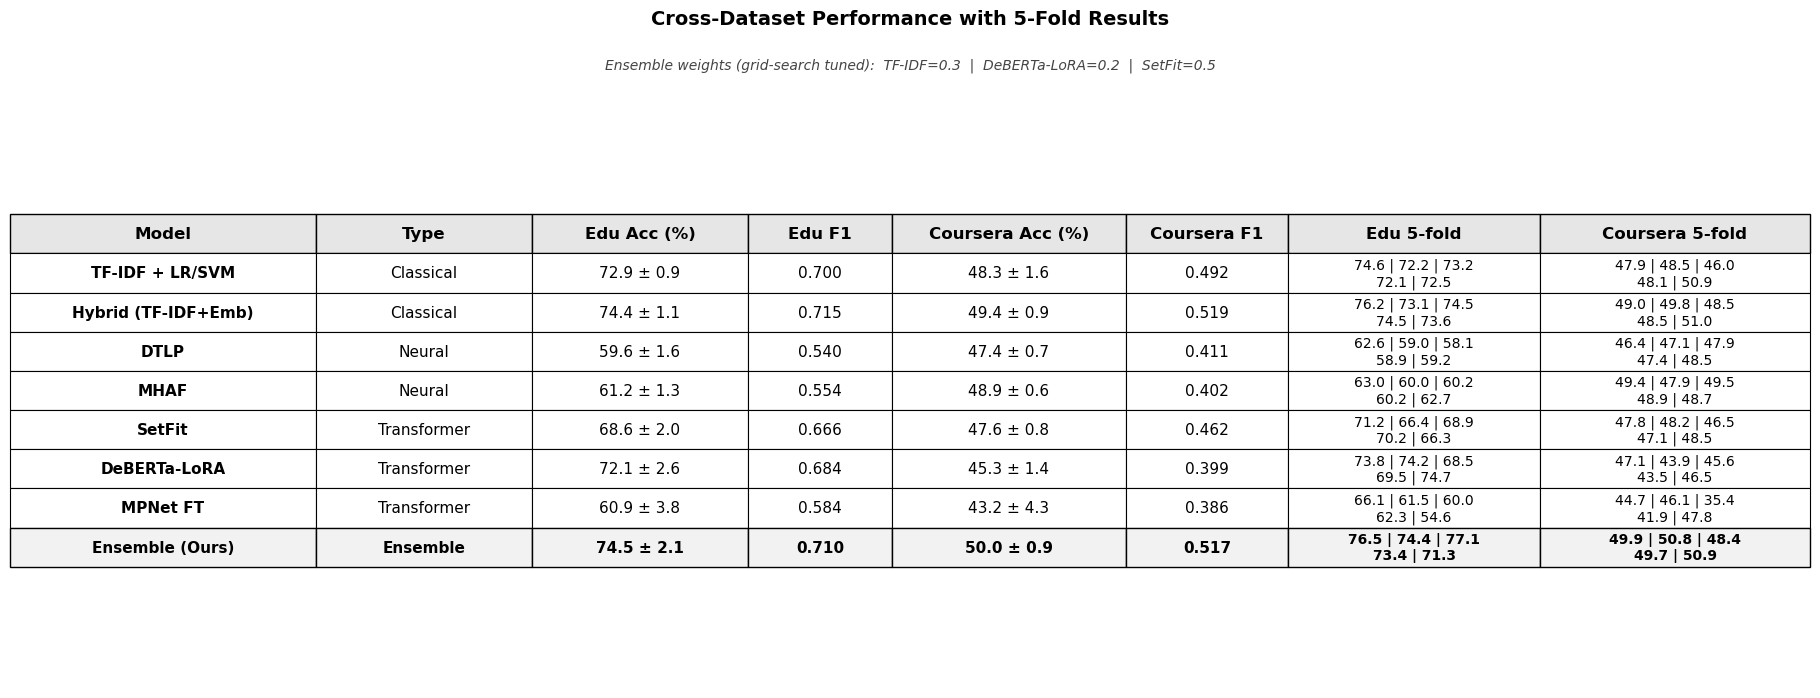

✅ Saved → output/results_table_diff_weights.png
   Weights shown: TF-IDF=0.3, DeBERTa=0.2, SetFit=0.5


In [14]:
import matplotlib.pyplot as plt

# =========================
# Data preparation
# =========================
all_models = [
    ("TF-IDF + LR/SVM",     results_tfidf,    "Classical"),
    ("Hybrid (TF-IDF+Emb)", results_hybrid,   "Classical"),
    ("DTLP",                results_dtlp,     "Neural"),
    ("MHAF",                results_mhaf,     "Neural"),
    ("SetFit",              results_setfit,   "Transformer"),
    ("DeBERTa-LoRA",        results_deberta,  "Transformer"),
    ("MPNet FT",            results_mpnet,    "Transformer"),
    ("Ensemble (Ours)",     results_ensemble, "Ensemble"),
]

def fmt_acc(r):
    m = r.get("accuracy_mean", 0) * 100
    s = r.get("accuracy_std", 0) * 100
    return f"{m:.1f} ± {s:.1f}"
def fmt_f1(r):
    return f"{r.get('f1_mean', 0):.3f}"
def fmt_folds_wrapped(r):
    folds = r.get("per_fold_acc", [])
    if not folds:
        return "—"
    vals = [f"{v*100:.1f}" for v in folds]
    if len(vals) == 5:
        return " | ".join(vals[:3]) + "\n" + " | ".join(vals[3:])
    return "\n".join(vals)

rows = []
for mname, rdict, group in all_models:
    edu = rdict.get("EduRABSA", {})
    cou = rdict.get("Coursera", {})
    rows.append([
        mname, group,
        fmt_acc(edu), fmt_f1(edu),
        fmt_acc(cou), fmt_f1(cou),
        fmt_folds_wrapped(edu), fmt_folds_wrapped(cou),
    ])

col_labels = ["Model", "Type", "Edu Acc (%)", "Edu F1",
              "Coursera Acc (%)", "Coursera F1", "Edu 5-fold", "Coursera 5-fold"]

# Pull best weights from grid search
_w = best_weights if 'best_weights' in dir() else tuple(CFG.get("ensemble_weights", [0.15, 0.20, 0.65]))
weight_label = f"Ensemble weights (grid-search tuned):  TF-IDF={_w[0]}  |  DeBERTa-LoRA={_w[1]}  |  SetFit={_w[2]}"

# =========================
# Figure — extra top margin for subtitle
# =========================
fig = plt.figure(figsize=(18, 7.0))
# Leave 15% at top for title + subtitle, 85% for table
ax = fig.add_axes([0, 0, 1, 0.85])   # [left, bottom, width, height]
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colLoc="center",
    colWidths=[0.17, 0.12, 0.12, 0.08, 0.13, 0.09, 0.14, 0.15]
)

# =========================
# Styling
# =========================
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.35)

header_color   = "#E6E6E6"
ensemble_color = "#F2F2F2"
n_cols = len(col_labels)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    if r == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(weight="bold", color="black", fontsize=12)
        cell.set_linewidth(1.0)
    else:
        cell.set_facecolor("white")
        if c == 0:
            cell.set_text_props(weight="bold")
        if c in [6, 7]:
            cell.set_text_props(fontsize=10)

# Highlight ensemble row
for i, row in enumerate(rows, start=1):
    if "Ensemble" in row[0]:
        for c in range(n_cols):
            table[(i, c)].set_facecolor(ensemble_color)
            table[(i, c)].set_text_props(weight="bold")
            table[(i, c)].set_linewidth(1.0)
        break

# =========================
# Title and subtitle — placed in top 15% of figure
# =========================
fig.text(0.5, 0.97,
         "Cross-Dataset Performance with 5-Fold Results",
         ha="center", va="top",
         fontsize=14, fontweight="bold")

fig.text(0.5, 0.90,
         weight_label,
         ha="center", va="top",
         fontsize=10, color="#444444", style="italic")

# =========================
# Save — no tight, no clipping
# =========================
out_png = f"{CFG['output_dir']}/results_table_diff_weights.png"
plt.savefig(out_png, dpi=300, facecolor="white")
plt.show()
print(f"✅ Saved → {out_png}")
print(f"   Weights shown: TF-IDF={_w[0]}, DeBERTa={_w[1]}, SetFit={_w[2]}")